# First part : Preprocessing the IEEE Fraud detection dataset


## Importing necessary packages

In [1]:
import pandas as pd
import gc
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler

## Reading raw data

In [2]:
# read dataset
train_trans = pd.read_csv('../train_transaction.csv')
train_id = pd.read_csv('../train_identity.csv')
test_trans = pd.read_csv('../test_transaction.csv')
test_id = pd.read_csv('../test_identity.csv')

In [3]:
#merge transaction and identity to have only one table for each train and test
train = pd.merge(train_id,train_trans,left_on='TransactionID',right_on='TransactionID',how='right')
test = pd.merge(test_id,test_trans,left_on='TransactionID',right_on='TransactionID',how='right')
train.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# free up some memory
del train_id
del train_trans
del test_id
del test_trans
gc.collect()

0

## Eliminating columns with a high number of missing values

In [5]:
# percentage of missing values per column
missing_pct = train.isnull().mean() * 100

# columns with more than 80% missing values
cols_to_drop = missing_pct[missing_pct > 80].index

# drop those columns
train = train.drop(columns=cols_to_drop)
test  = test.drop(columns=cols_to_drop, errors='ignore')

# optional: inspect what was removed
missing_summary = missing_pct.sort_values(ascending=False)
missing_summary.head()


id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
dtype: float64

## Handling missing values

In [6]:
# For categorical columns in both train and test
for col in train.select_dtypes(include=['object']).columns:
    # Fill train
    mode_val = train[col].mode()[0] if not train[col].mode().empty else 'Unknown'
    train[col] = train[col].fillna(mode_val)
    
    # Fill test with same mode (if column exists)
    if col in test.columns:
        test[col] = test[col].fillna(mode_val)

# For numerical columns in both train and test
for col in train.select_dtypes(exclude=['object']).columns:
    # Fill train
    mean_val = train[col].mean()
    train[col] = train[col].fillna(mean_val)
    
    # Fill test with same mean (if column exists)
    if col in test.columns:
        test[col] = test[col].fillna(mean_val)

print("Missing values in train:", train.isnull().sum().sum())
print("Missing values in test:", test.isnull().sum().sum())

Missing values in train: 0
Missing values in test: 0


## split train data to features and labels

## Encode categorical columns 

In [7]:
cat_col=[]
for col in train:
  if train[col].dtype == 'object':
    cat_col.append(col)
encoders = {}
for col in cat_col:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str).values)
    encoders[col] = le
  

for col in cat_col:
    if col in test.columns:
        test[col] = test[col].astype(str)
        # Create array for transformation
        encoded_values = []
        for val in test[col]:
            if val in encoders[col].classes_:
                encoded_values.append(encoders[col].transform([val])[0])
            else:
                encoded_values.append(-1)
        test[col] = encoded_values

In [8]:
gc.collect()

0

In [9]:
train_y = train['isFraud']
train_x = train.drop(columns=['isFraud'])

<Axes: xlabel='isFraud'>

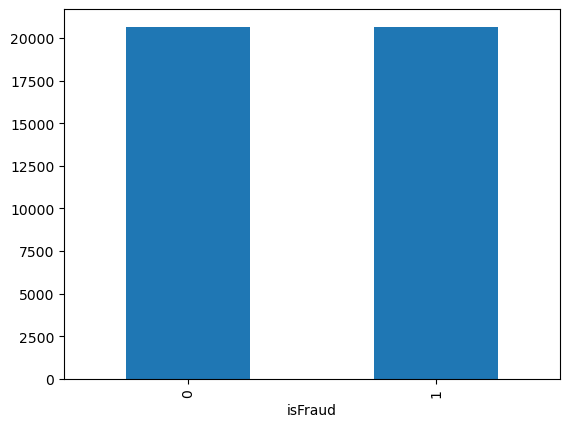

In [10]:
train_x, train_y = RandomUnderSampler().fit_resample(train_x, train_y)
train_y.value_counts().plot.bar()

In [ ]:
train_x.to_csv('../preprocessed dataset/X_train.csv', index=False)
test.to_csv('../preprocessed dataset/X_test.csv', index=False)
train_y.to_csv('../preprocessed dataset/y_train.csv', index=False)